In [110]:
import numpy as np 
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.neural_network import MLPClassifier
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

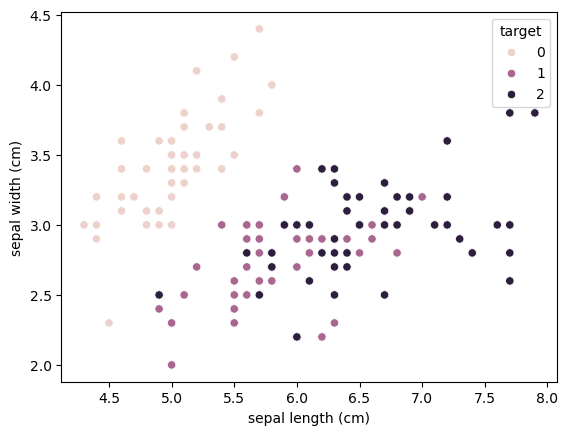

In [111]:
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
sns.scatterplot(data=X, x=X.iloc[:,0], y=X.iloc[:,1], hue=y)

In [112]:
Xtrain, Xtest, yTrain, yTest = train_test_split(X, y, stratify=y, random_state=67, test_size=0.15)
Xtrain, Xtest, yTrain, yTest

(     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 57                 4.9               2.4                3.3               1.0
 23                 5.1               3.3                1.7               0.5
 12                 4.8               3.0                1.4               0.1
 63                 6.1               2.9                4.7               1.4
 20                 5.4               3.4                1.7               0.2
 ..                 ...               ...                ...               ...
 71                 6.1               2.8                4.0               1.3
 10                 5.4               3.7                1.5               0.2
 129                7.2               3.0                5.8               1.6
 39                 5.1               3.4                1.5               0.2
 111                6.4               2.7                5.3               1.9
 
 [127 rows x 4 columns],
      sepal length (cm)  

In [113]:
modelPipeline = Pipeline([
    ("scale", StandardScaler()),
    ("train", MLPClassifier(hidden_layer_sizes=[3, 24, 24, 3], random_state=67, learning_rate="adaptive", max_iter=135000, alpha=0.001, learning_rate_init=0.003))
])

In [114]:
modelPipeline.fit(Xtrain, yTrain)

,steps,"[('scale', ...), ('train', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"[3, 24, ...]"
,activation,'relu'
,solver,'adam'
,alpha,0.001


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         7

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



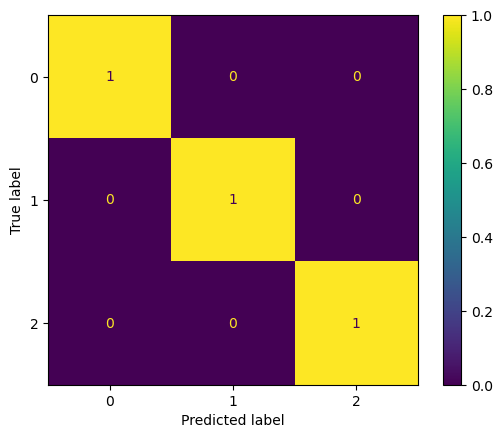

Accuracy score: 100%


In [115]:
yPredOnTest = modelPipeline.predict(Xtest)
print(classification_report(yTest, yPredOnTest))
ConfusionMatrixDisplay.from_predictions(y_true=yTest, y_pred=yPredOnTest, normalize="true")
plt.show()
print(f"Accuracy score: {round(accuracy_score(yTest, yPredOnTest)*100)}%")